# Hyperalignment Results — Visualization
Plots for all 5 steps of the Procrustes hyperalignment pipeline.
Outputs saved to `hyperalignment_results/figures/`

In [1]:
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import nibabel as nib
from pathlib import Path
from nilearn import plotting
from itertools import combinations
from scipy.stats import pearsonr

sys.path.insert(0, str(Path('').resolve()))
from utils import TASKS, CONTRASTS, SUBJECTS, ENCOUNTERS

RESULTS_DIR = Path('hyperalignment_results')
FIG_DIR     = RESULTS_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

# Load all outputs
with open(RESULTS_DIR / 'lme_results_aligned.pkl', 'rb') as f:
    lme_results = pickle.load(f)

with open(RESULTS_DIR / 'procrustes_rotations.pkl', 'rb') as f:
    rot_data = pickle.load(f)
rotations  = rot_data['rotations']
row_labels = rot_data['row_labels']
template   = rot_data['template']   # (35 x 429)

isc_df      = pd.read_csv(RESULTS_DIR / 'isc_by_encounter.csv')
decoding_df = pd.read_csv(RESULTS_DIR / 'decoding_by_encounter.csv')

# Load smorgasbord atlas
with open('smorgasbord_atlas_files/smorgasbord_atlas.pkl', 'rb') as f:
    smor = pickle.load(f)
atlas_img  = smor.maps
atlas_data = atlas_img.get_fdata()
atlas_labels = [l.decode() if isinstance(l, bytes) else l for l in smor.labels]

print(f'LME tasks: {list(lme_results.keys())}')
print(f'Template shape: {template.shape}')
print(f'Atlas parcels: {len(atlas_labels)}')

LME tasks: ['nBack', 'flanker', 'directedForgetting', 'goNogo', 'shapeMatching', 'stopSignal', 'cuedTS', 'spatialTS']
Template shape: (35, 429)
Atlas parcels: 429


## Figure 1 — Alignment Validation: ISC and Cross-Subject Decoding
Top: mean ISC across encounters before vs after alignment.  
Bottom: cross-subject decoding accuracy before vs after alignment.  
Both validate that Procrustes put subjects into a common space.

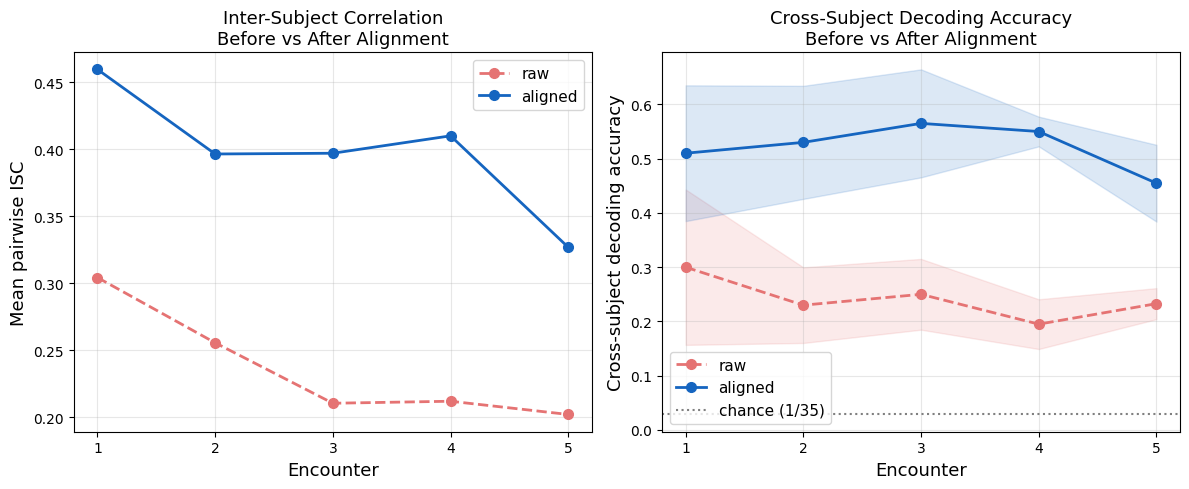

Saved fig1_alignment_validation.png


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- ISC panel ---
isc_summary = isc_df.groupby(['encounter', 'aligned'])['mean_isc'].mean().reset_index()

# The 'aligned' column was set by positional index in the pipeline — fix labels here
half = len(isc_df) // 2
isc_df['condition'] = ['raw'] * half + ['aligned'] * half
isc_summary = isc_df.groupby(['encounter', 'condition'])['mean_isc'].mean().reset_index()

for cond, color, ls in [('raw', '#E57373', '--'), ('aligned', '#1565C0', '-')]:
    d = isc_summary[isc_summary['condition'] == cond]
    axes[0].plot(d['encounter'], d['mean_isc'], marker='o', color=color,
                 linestyle=ls, linewidth=2, markersize=7, label=cond)

axes[0].set_xlabel('Encounter', fontsize=13)
axes[0].set_ylabel('Mean pairwise ISC', fontsize=13)
axes[0].set_title('Inter-Subject Correlation\nBefore vs After Alignment', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].set_xticks([1,2,3,4,5])
axes[0].grid(True, alpha=0.3)

# --- Decoding panel ---
for cond, color, ls in [('raw', '#E57373', '--'), ('aligned', '#1565C0', '-')]:
    d = decoding_df[decoding_df['label'] == cond]
    axes[1].plot(d['encounter'], d['mean_accuracy'], marker='o', color=color,
                 linestyle=ls, linewidth=2, markersize=7, label=cond)
    axes[1].fill_between(d['encounter'],
                          d['mean_accuracy'] - d['std_accuracy'],
                          d['mean_accuracy'] + d['std_accuracy'],
                          alpha=0.15, color=color)

axes[1].axhline(1/35, color='gray', linestyle=':', linewidth=1.5, label='chance (1/35)')
axes[1].set_xlabel('Encounter', fontsize=13)
axes[1].set_ylabel('Cross-subject decoding accuracy', fontsize=13)
axes[1].set_title('Cross-Subject Decoding Accuracy\nBefore vs After Alignment', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].set_xticks([1,2,3,4,5])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_alignment_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig1_alignment_validation.png')

## Figure 2 — Significant Parcels per Task/Contrast (LME FDR q<0.05)
Bar chart showing what fraction of the 429 parcels show significant practice effects
in aligned space.

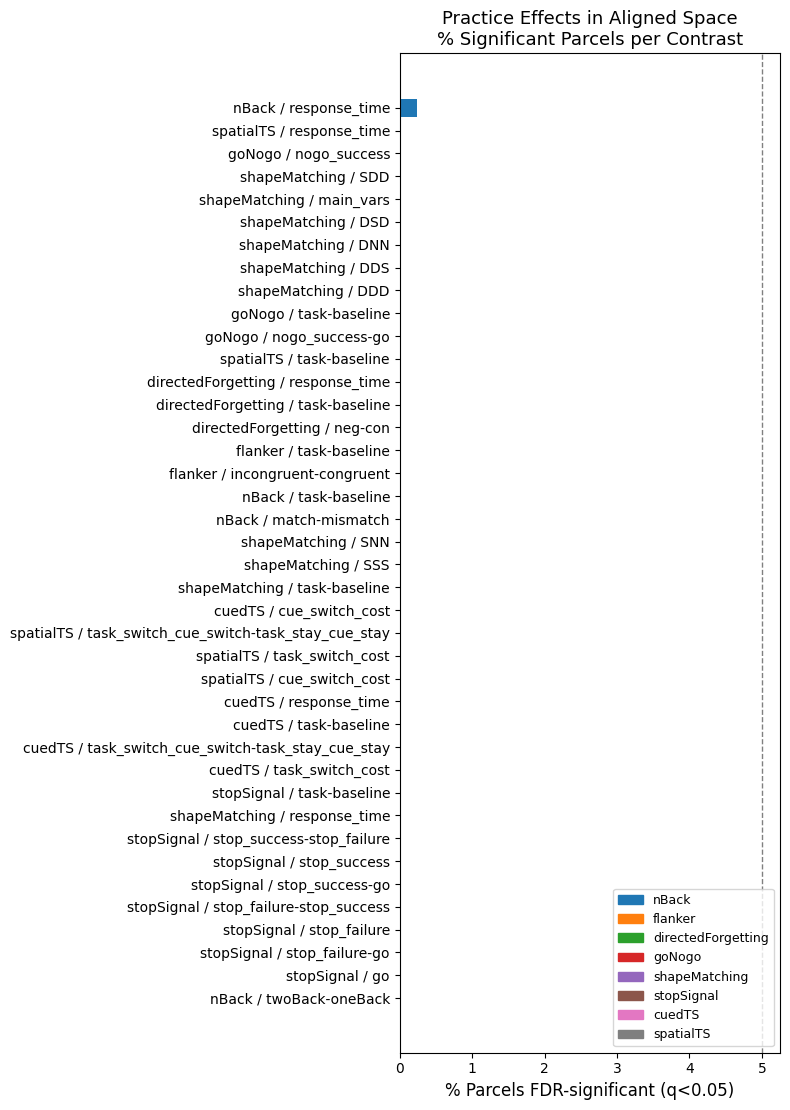

Saved fig2_significant_parcels.png


In [3]:
sig_rows = []
for task in lme_results:
    for contrast, df_res in lme_results[task].items():
        n_sig = df_res['fdr_significant'].sum()
        sig_rows.append({'task': task, 'contrast': contrast,
                         'n_sig': n_sig, 'pct_sig': 100 * n_sig / 429})
sig_df = pd.DataFrame(sig_rows).sort_values('pct_sig', ascending=True)

# Color by task
task_colors = dict(zip(TASKS, sns.color_palette('tab10', len(TASKS))))
colors = [task_colors[r] for r in sig_df['task']]

fig, ax = plt.subplots(figsize=(8, max(6, len(sig_df)*0.28)))
labels  = [f"{r['task']} / {r['contrast']}" for _, r in sig_df.iterrows()]
ax.barh(labels, sig_df['pct_sig'], color=colors)
ax.set_xlabel('% Parcels FDR-significant (q<0.05)', fontsize=12)
ax.set_title('Practice Effects in Aligned Space\n% Significant Parcels per Contrast', fontsize=13)
ax.axvline(5, color='gray', linestyle='--', linewidth=1, label='5% reference')
ax.legend(fontsize=10)

# Legend for task colors
from matplotlib.patches import Patch
legend_handles = [Patch(color=task_colors[t], label=t) for t in TASKS]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_significant_parcels.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig2_significant_parcels.png')

## Figure 3 — Brain Maps of Practice Effect Slopes
For each task, plot the fixed-effect slope (from LME) on the brain surface.
Warm = increasing activation with practice; cool = decreasing.

/tmp/ipykernel_4562/2827062978.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


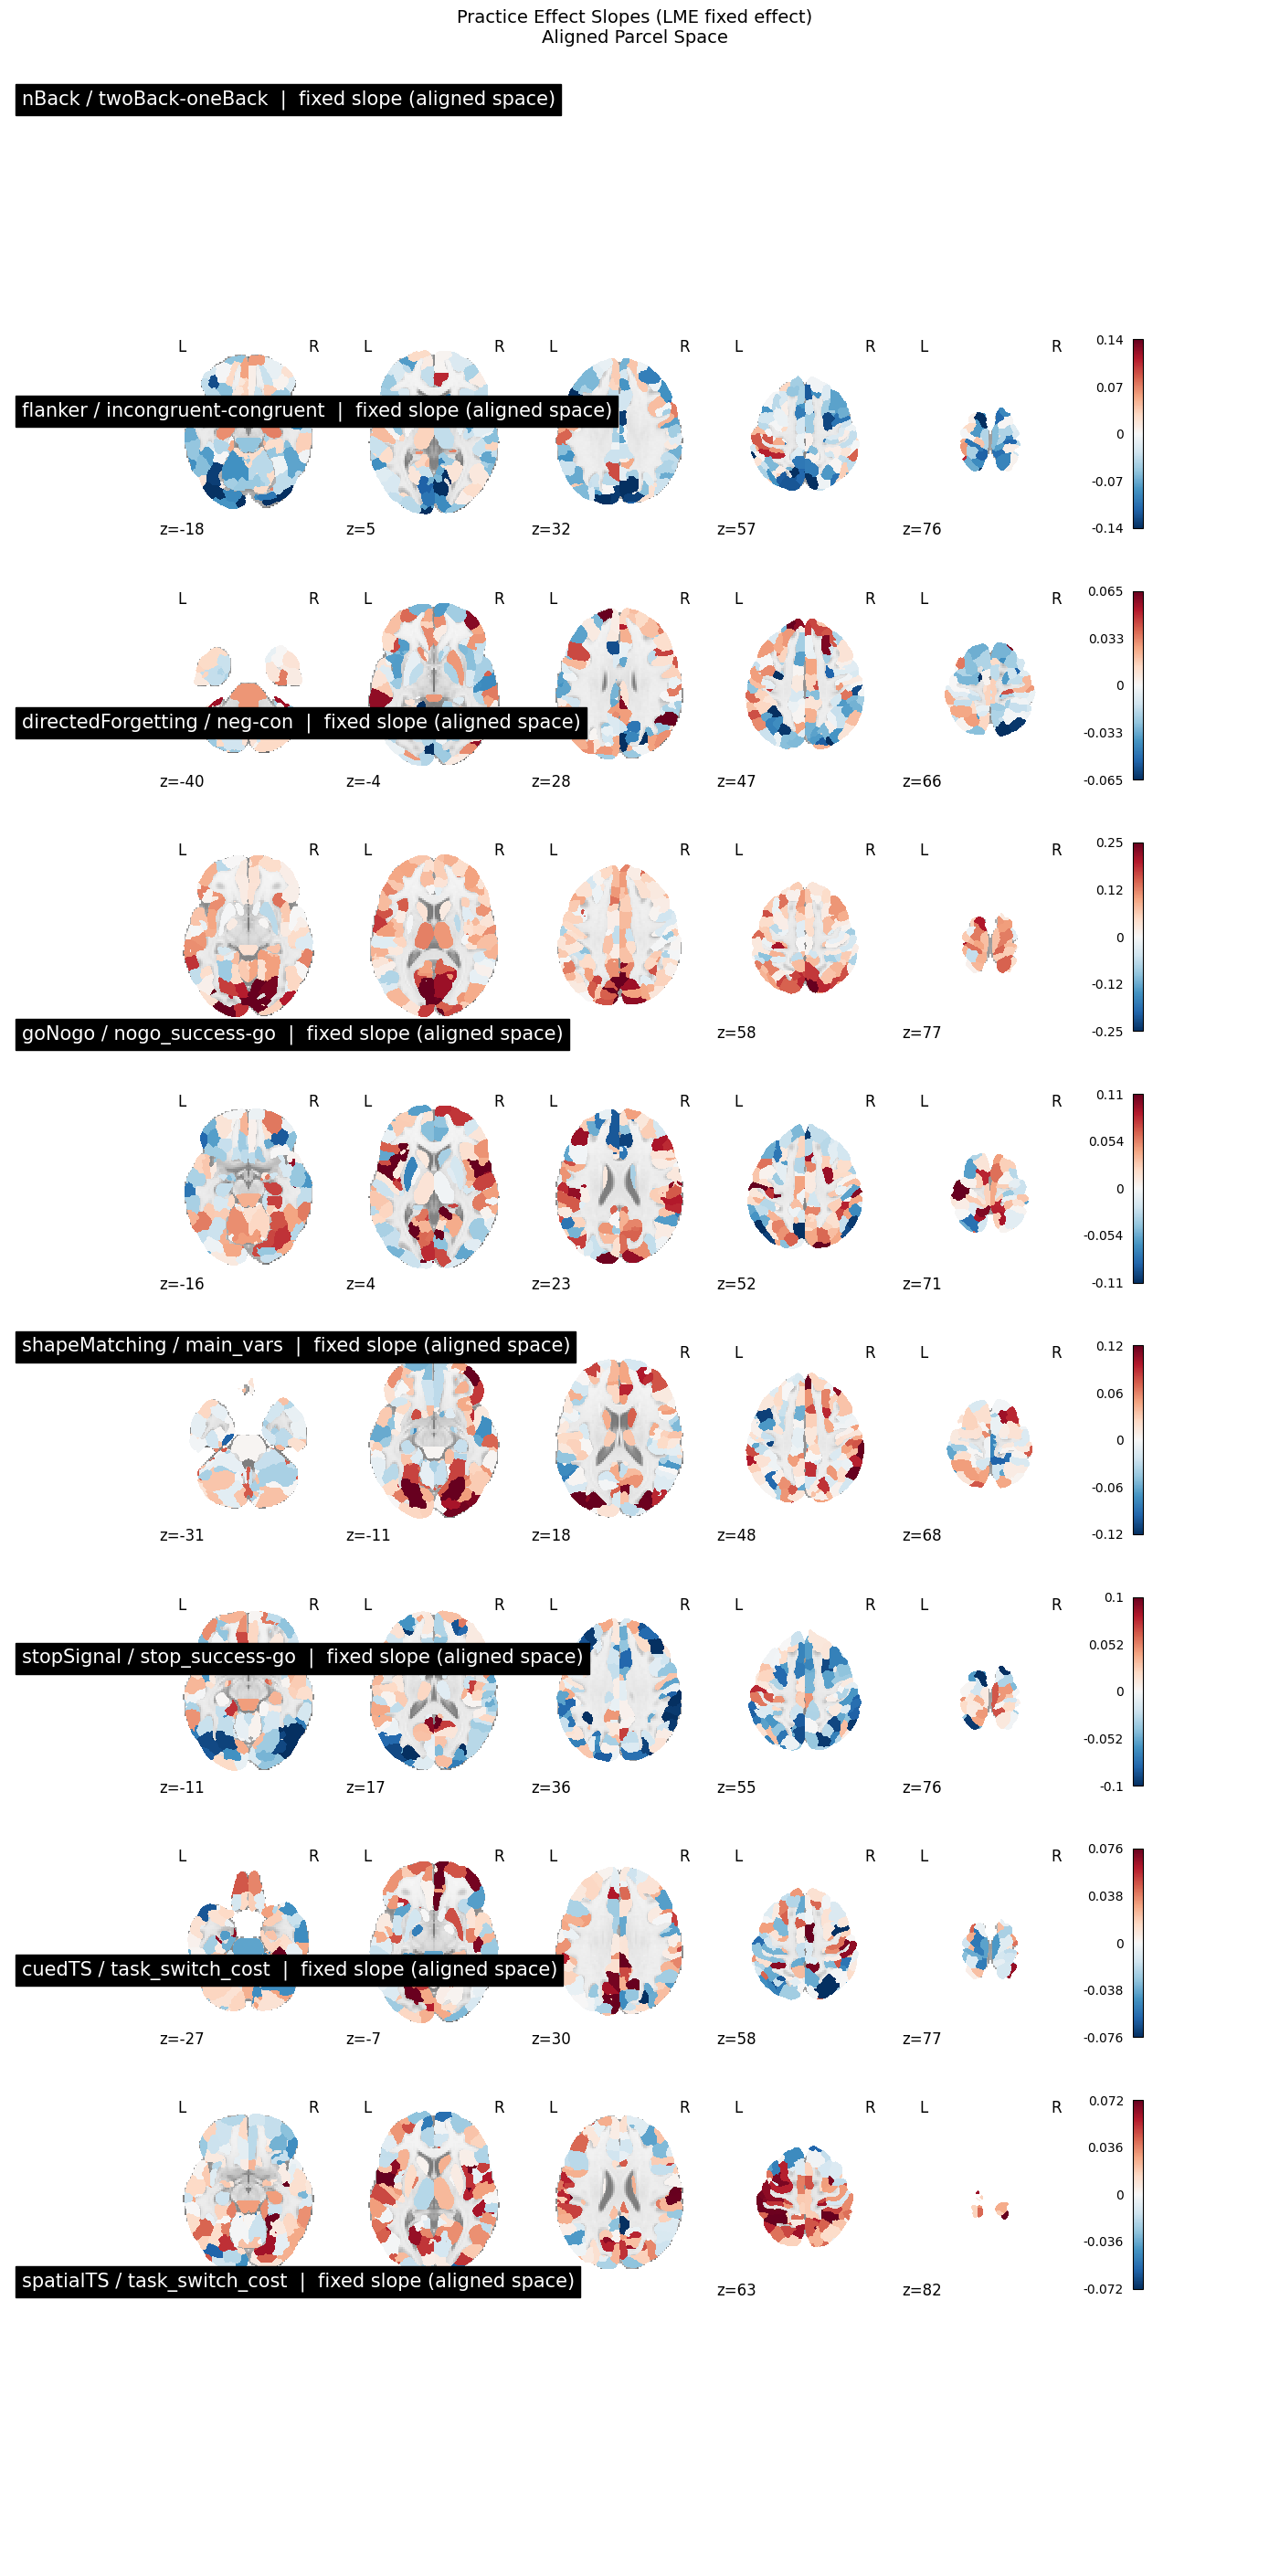

Saved fig3_brain_maps_slopes.png


In [4]:
def parcel_values_to_nifti(values_by_parcel_idx, atlas_data, atlas_labels, roi_values, affine):
    """
    Map a {parcel_idx -> value} dict onto the atlas volume.
    Returns a NIfTI image.
    """
    vol = np.zeros_like(atlas_data)
    for idx, val in values_by_parcel_idx.items():
        if np.isnan(val):
            continue
        roi_val = roi_values[idx]
        vol[atlas_data == roi_val] = val
    return nib.Nifti1Image(vol, affine)


# Choose one representative contrast per task
KEY_CONTRASTS = {
    'nBack':              'twoBack-oneBack',
    'flanker':            'incongruent-congruent',
    'directedForgetting': 'neg-con',
    'goNogo':             'nogo_success-go',
    'shapeMatching':      'main_vars',
    'stopSignal':         'stop_success-go',
    'cuedTS':             'task_switch_cost',
    'spatialTS':          'task_switch_cost',
}

n_tasks = len(KEY_CONTRASTS)
fig, axes = plt.subplots(n_tasks, 1, figsize=(14, 3.5 * n_tasks))

for ax, (task, contrast) in zip(axes, KEY_CONTRASTS.items()):
    if task not in lme_results or contrast not in lme_results[task]:
        ax.set_visible(False)
        continue

    df_res = lme_results[task][contrast]
    val_dict = dict(zip(df_res['parcel_idx'], df_res['fixed_slope']))
    slope_img = parcel_values_to_nifti(val_dict, atlas_data, atlas_labels,
                                        smor.roi_values, atlas_img.affine)

    nonzero = df_res['fixed_slope'].dropna()
    vmax = np.percentile(np.abs(nonzero), 97)

    display = plotting.plot_stat_map(
        slope_img, display_mode='z', cut_coords=5,
        colorbar=True, cmap='RdBu_r',
        vmax=vmax, symmetric_cbar=True,
        title=f'{task} / {contrast}  |  fixed slope (aligned space)',
        axes=ax
    )

plt.suptitle('Practice Effect Slopes (LME fixed effect)\nAligned Parcel Space',
             fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_brain_maps_slopes.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved fig3_brain_maps_slopes.png')

## Figure 4 — FDR-Masked Brain Maps
Same as Fig 3 but only show parcels where the practice effect is FDR-significant (q<0.05).

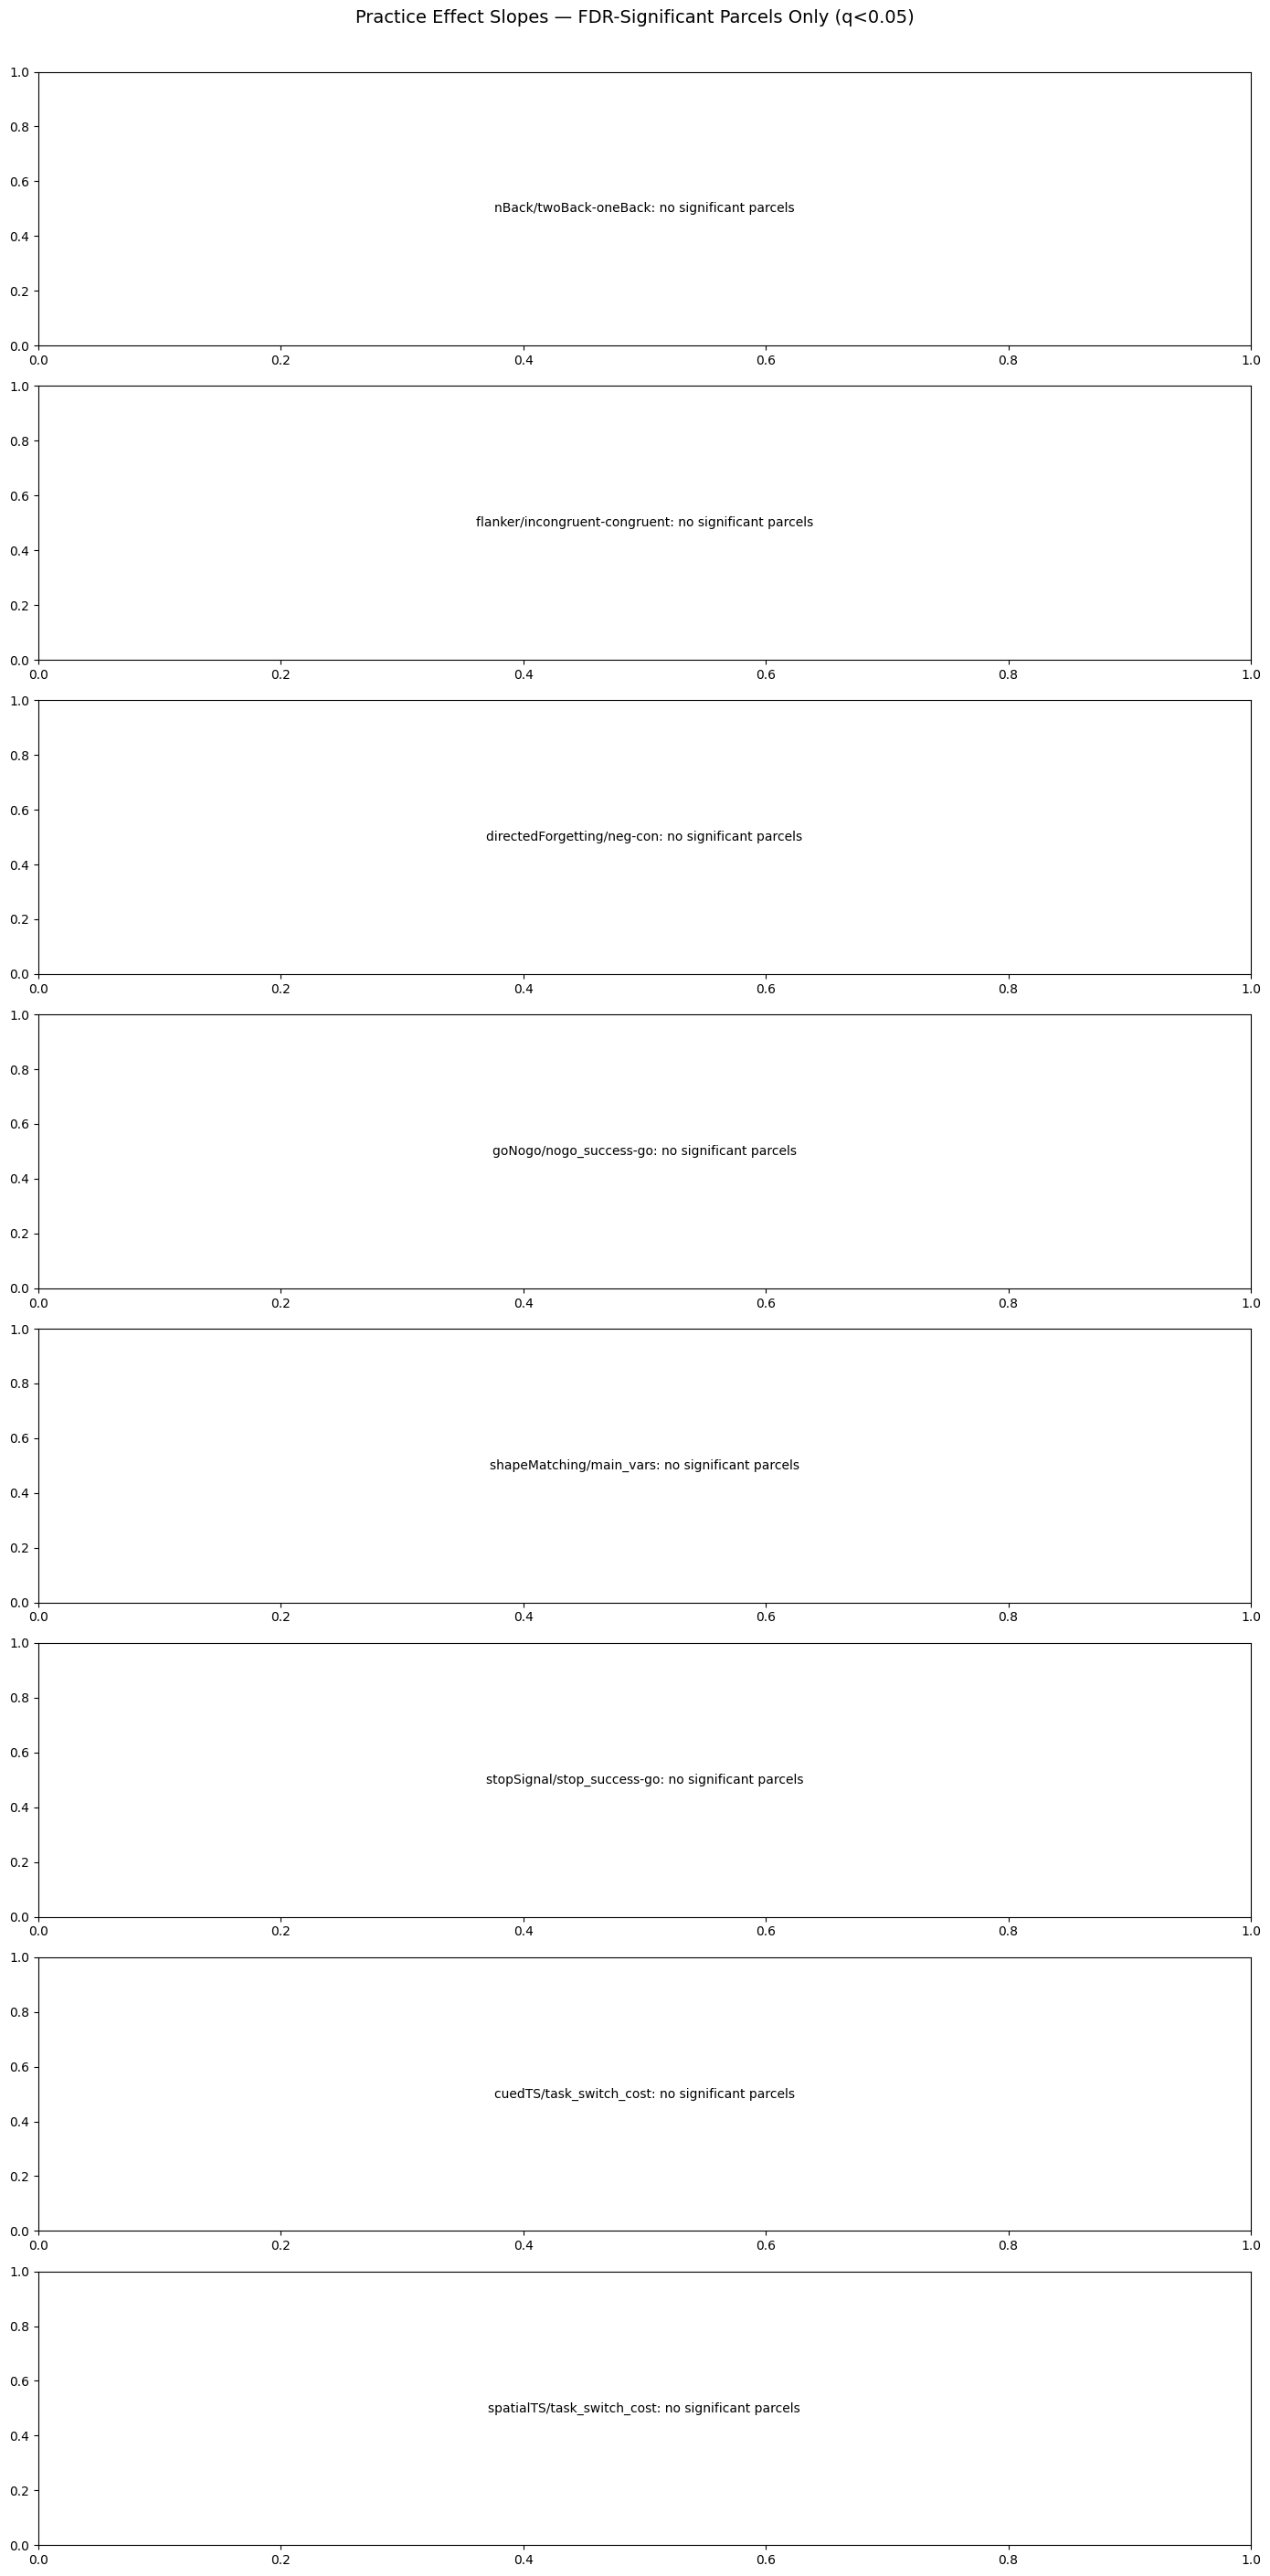

Saved fig4_brain_maps_fdr.png


In [5]:
fig, axes = plt.subplots(n_tasks, 1, figsize=(14, 3.5 * n_tasks))

for ax, (task, contrast) in zip(axes, KEY_CONTRASTS.items()):
    if task not in lme_results or contrast not in lme_results[task]:
        ax.set_visible(False)
        continue

    df_res = lme_results[task][contrast]
    # Only include FDR-significant parcels
    val_dict = {
        int(row['parcel_idx']): row['fixed_slope']
        for _, row in df_res.iterrows()
        if row['fdr_significant'] and not np.isnan(row['fixed_slope'])
    }
    n_sig = len(val_dict)

    if n_sig == 0:
        ax.text(0.5, 0.5, f'{task}/{contrast}: no significant parcels',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_visible(True)
        continue

    slope_img = parcel_values_to_nifti(val_dict, atlas_data, atlas_labels,
                                        smor.roi_values, atlas_img.affine)
    all_sig_vals = np.array(list(val_dict.values()))
    vmax = np.percentile(np.abs(all_sig_vals), 97) if len(all_sig_vals) else 0.1

    plotting.plot_stat_map(
        slope_img, display_mode='z', cut_coords=5,
        colorbar=True, cmap='RdBu_r',
        vmax=vmax, symmetric_cbar=True,
        title=f'{task} / {contrast}  |  {n_sig}/429 FDR-sig parcels',
        axes=ax
    )

plt.suptitle('Practice Effect Slopes — FDR-Significant Parcels Only (q<0.05)',
             fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_brain_maps_fdr.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved fig4_brain_maps_fdr.png')

## Figure 5 — Network-Level Practice Effects
Average the fixed slope across parcels within each 7-Network label.
Shows which large-scale networks increase or decrease activation with practice.

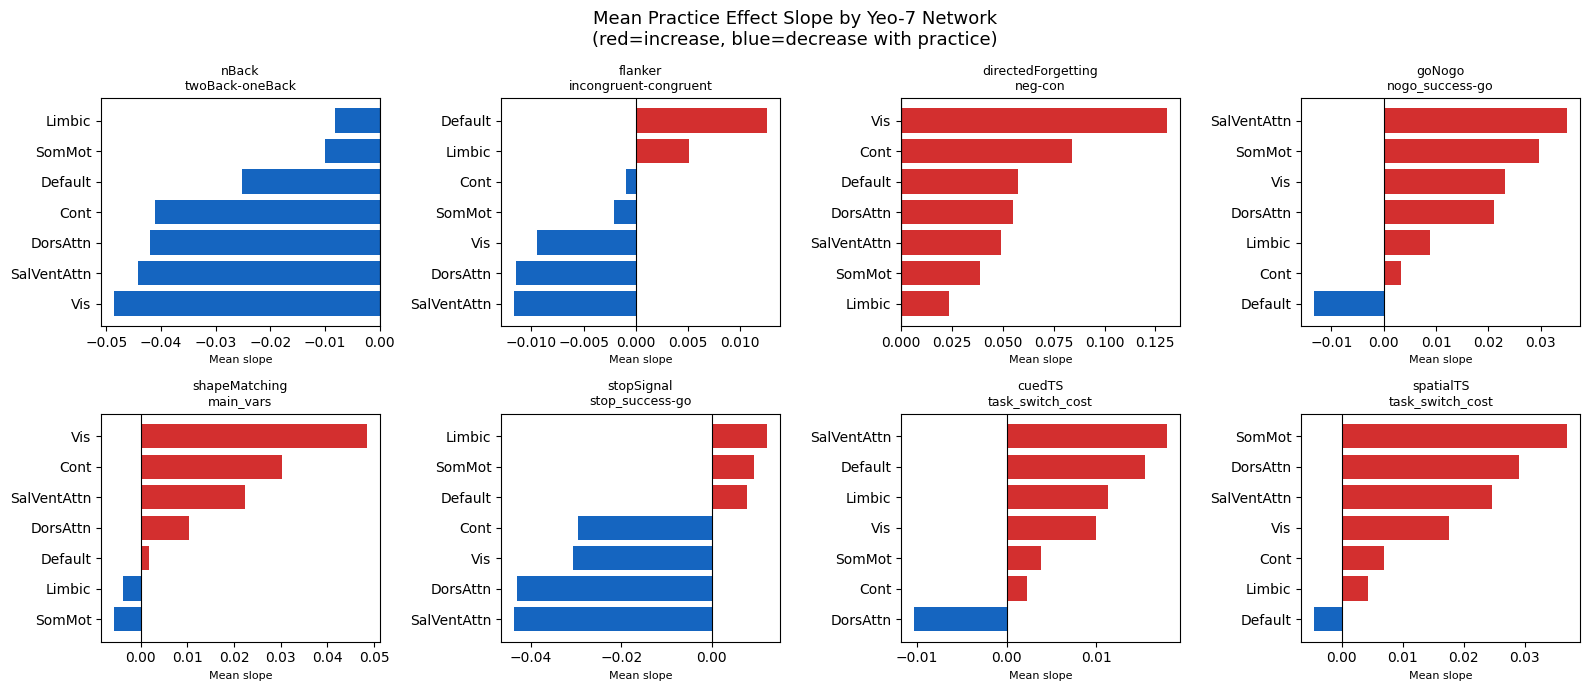

Saved fig5_network_slopes.png


In [6]:
# Map parcel index to 7-network label
def get_network(label):
    """Extract Yeo-7 network name from atlas label string."""
    if '7Networks' in label:
        parts = label.split('_')
        # Format: 7Networks_LH_Vis_1 -> Vis
        hemi = parts[1]  # LH or RH
        net  = parts[2]  # Vis, SomMot, DorsAttn, etc.
        return f'{net}'
    else:
        return label.split('_')[0]  # e.g. 'amygdala'

parcel_networks = [get_network(l) for l in atlas_labels]

network_rows = []
for task, contrast in KEY_CONTRASTS.items():
    if task not in lme_results or contrast not in lme_results[task]:
        continue
    df_res = lme_results[task][contrast]
    for _, row in df_res.iterrows():
        idx = int(row['parcel_idx'])
        network_rows.append({
            'task':     task,
            'contrast': contrast,
            'network':  parcel_networks[idx],
            'slope':    row['fixed_slope'],
            'fdr_sig':  row['fdr_significant'],
        })

net_df = pd.DataFrame(network_rows)

# Keep only 7Networks parcels for cleaner plot
net7_df = net_df[net_df['network'].isin(['Vis','SomMot','DorsAttn','SalVentAttn','Limbic','Cont','Default'])]

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.flatten()

for ax, (task, contrast) in zip(axes, KEY_CONTRASTS.items()):
    d = net7_df[(net7_df['task'] == task) & (net7_df['contrast'] == contrast)]
    if d.empty:
        ax.set_visible(False)
        continue
    net_mean = d.groupby('network')['slope'].mean().reset_index()
    net_mean = net_mean.sort_values('slope')
    colors = ['#D32F2F' if v > 0 else '#1565C0' for v in net_mean['slope']]
    ax.barh(net_mean['network'], net_mean['slope'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{task}\n{contrast}', fontsize=9)
    ax.set_xlabel('Mean slope', fontsize=8)

for ax in axes[len(KEY_CONTRASTS):]:
    ax.set_visible(False)

plt.suptitle('Mean Practice Effect Slope by Yeo-7 Network\n(red=increase, blue=decrease with practice)',
             fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_network_slopes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig5_network_slopes.png')

## Figure 6 — Procrustes Template Heatmap
The (35 contrasts × 429 parcels) shared template from Step 2.
Rows = contrast labels, columns = parcels sorted by network. Shows the shared
representational geometry that all subjects were aligned to.

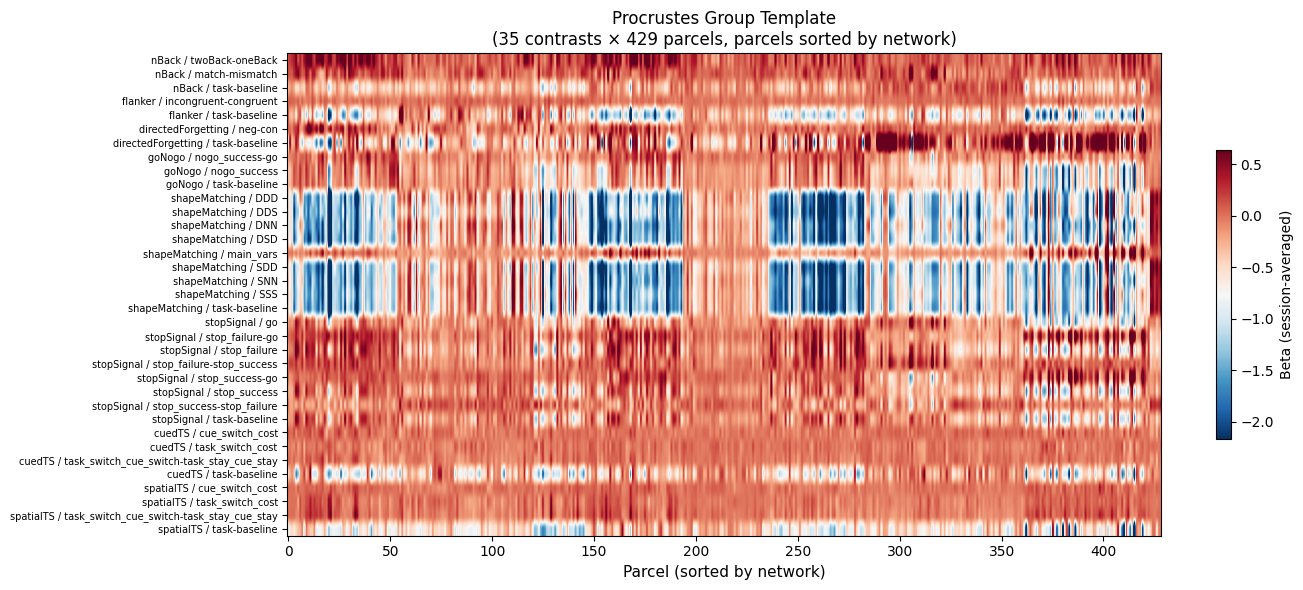

Saved fig6_template_heatmap.png


In [7]:
# Sort parcels by network for cleaner visualization
sort_idx = np.argsort(parcel_networks)
template_sorted = template[:, sort_idx]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(template_sorted, aspect='auto', cmap='RdBu_r',
               vmin=np.percentile(template, 2), vmax=np.percentile(template, 98))
plt.colorbar(im, ax=ax, shrink=0.6, label='Beta (session-averaged)')

ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels([l.replace('__', ' / ') for l in row_labels], fontsize=7)
ax.set_xlabel('Parcel (sorted by network)', fontsize=11)
ax.set_title('Procrustes Group Template\n(35 contrasts × 429 parcels, parcels sorted by network)',
             fontsize=12)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig6_template_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig6_template_heatmap.png')

## Figure 7 — ISC Trajectory: Neural Individuation with Practice
ISC decreasing across encounters = subjects become more *idiosyncratic* with practice
(neural individuation). Plot broken out by task family.

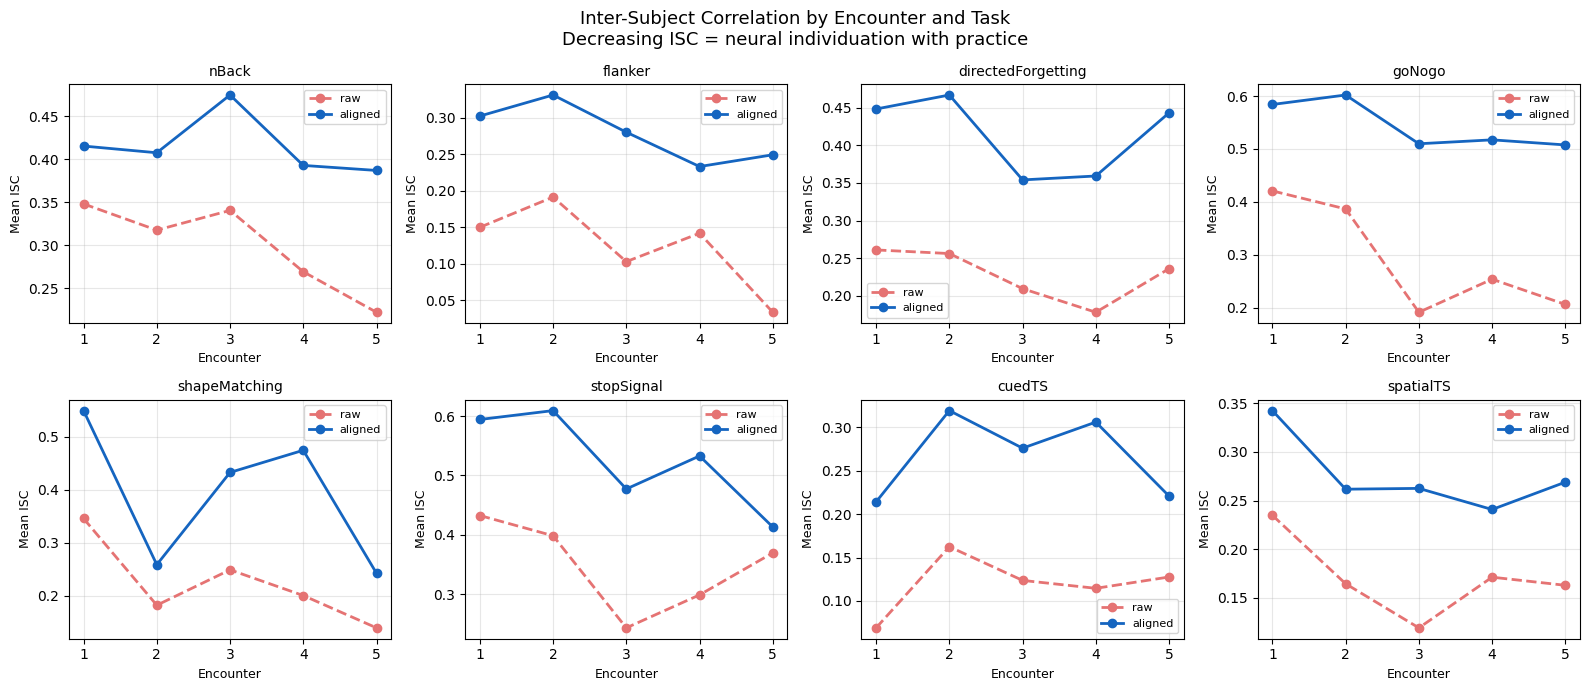

Saved fig7_isc_by_task.png


In [8]:
# Fix condition labels (same approach as Fig 1)
half = len(isc_df) // 2
isc_df = pd.read_csv(RESULTS_DIR / 'isc_by_encounter.csv')  # reload clean
isc_df['condition'] = ['raw'] * half + ['aligned'] * half

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.flatten()

for ax, task in zip(axes, TASKS):
    task_df = isc_df[isc_df['task'] == task]
    if task_df.empty:
        ax.set_visible(False)
        continue

    for cond, color, ls in [('raw', '#E57373', '--'), ('aligned', '#1565C0', '-')]:
        d = task_df[task_df['condition'] == cond].groupby('encounter')['mean_isc'].mean().reset_index()
        ax.plot(d['encounter'], d['mean_isc'], marker='o', color=color,
                linestyle=ls, linewidth=2, markersize=6, label=cond)

    ax.set_title(task, fontsize=10)
    ax.set_xlabel('Encounter', fontsize=9)
    ax.set_ylabel('Mean ISC', fontsize=9)
    ax.set_xticks([1,2,3,4,5])
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[len(TASKS):]:
    ax.set_visible(False)

plt.suptitle('Inter-Subject Correlation by Encounter and Task\n'
             'Decreasing ISC = neural individuation with practice', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig7_isc_by_task.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig7_isc_by_task.png')

## Figure 8 — Per-Subject Rotation Matrices
Visualize how much each subject was rotated by Procrustes.
A near-identity matrix = subject was already close to the group template.
High off-diagonal values = subject needed significant re-organization.

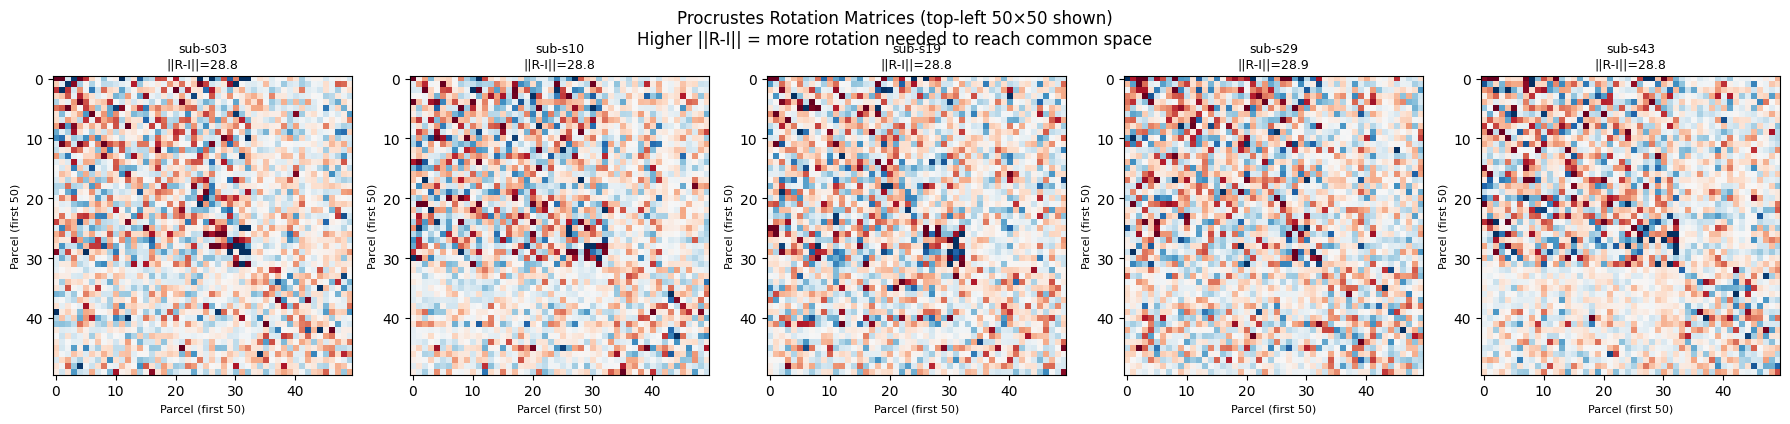

Saved fig8_rotation_matrices.png


In [9]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, subj in zip(axes, SUBJECTS):
    R = rotations[subj]
    # How far from identity? Frobenius norm of (R - I)
    dist_from_identity = np.linalg.norm(R - np.eye(R.shape[0]), 'fro')
    # Show top-left 50x50 for visibility
    im = ax.imshow(R[:50, :50], cmap='RdBu_r', vmin=-0.15, vmax=0.15)
    ax.set_title(f'{subj}\n||R-I||={dist_from_identity:.1f}', fontsize=9)
    ax.set_xlabel('Parcel (first 50)', fontsize=8)
    ax.set_ylabel('Parcel (first 50)', fontsize=8)

plt.suptitle('Procrustes Rotation Matrices (top-left 50×50 shown)\n'
             'Higher ||R-I|| = more rotation needed to reach common space', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig8_rotation_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig8_rotation_matrices.png')

## Summary Table — Key Numbers

In [10]:
print('=== ALIGNMENT QUALITY ===')
print(f'Mean ISC raw:     {isc_df[isc_df["condition"]=="raw"]["mean_isc"].mean():.3f}')
print(f'Mean ISC aligned: {isc_df[isc_df["condition"]=="aligned"]["mean_isc"].mean():.3f}')
print()
print(f'Mean decoding raw:     {decoding_df[decoding_df["label"]=="raw"]["mean_accuracy"].mean():.3f}')
print(f'Mean decoding aligned: {decoding_df[decoding_df["label"]=="aligned"]["mean_accuracy"].mean():.3f}')
print(f'Chance level (1/35):   {1/35:.3f}')
print()
print('=== ROTATION MAGNITUDES ===')
for subj in SUBJECTS:
    R = rotations[subj]
    print(f'  {subj}: ||R - I|| = {np.linalg.norm(R - np.eye(R.shape[0]), "fro"):.2f}')
print()
print('=== TOP 5 CONTRASTS BY % SIGNIFICANT PARCELS ===')
print(sig_df.sort_values('pct_sig', ascending=False)[['task','contrast','n_sig','pct_sig']].head(10).to_string(index=False))

=== ALIGNMENT QUALITY ===
Mean ISC raw:     0.237
Mean ISC aligned: 0.398

Mean decoding raw:     0.242
Mean decoding aligned: 0.522
Chance level (1/35):   0.029

=== ROTATION MAGNITUDES ===
  sub-s03: ||R - I|| = 28.82
  sub-s10: ||R - I|| = 28.84
  sub-s19: ||R - I|| = 28.80
  sub-s29: ||R - I|| = 28.88
  sub-s43: ||R - I|| = 28.84

=== TOP 5 CONTRASTS BY % SIGNIFICANT PARCELS ===
              task              contrast  n_sig  pct_sig
             nBack         response_time      1   0.2331
        stopSignal                    go      0   0.0000
             nBack         task-baseline      0   0.0000
           flanker incongruent-congruent      0   0.0000
           flanker         task-baseline      0   0.0000
directedForgetting               neg-con      0   0.0000
directedForgetting         task-baseline      0   0.0000
directedForgetting         response_time      0   0.0000
         spatialTS         task-baseline      0   0.0000
            goNogo       nogo_success-go    